In [2]:
##### IMPORTS

import os, re
import numpy as np
import matplotlib.pyplot as plt

In [9]:
##### CLOUD FREE CONFIGURATION

file1 = r"C:\Users\Alex\Desktop\Picaso\NN_project\compare_cases\Pt790.3769135035916g2056.7149450539773.npy"
file2 = r"C:\Users\Alex\Desktop\Picaso\NN_project\compare_cases\At790.3769135035916g2056.7149450539773.npy"

def clfree_name(path):
    base = os.path.basename(path)
    m = re.search(r"t(?P<T>[0-9.]+)g(?P<G>[0-9.]+)\.npy$", base)
    if m is None:
        raise ValueError(f"Could not parse T,g from filename: {base}")
    T = float(m.group("T"))
    g = float(m.group("G"))
    return T, g

def clfree_flux(file):
    # Loading in the flux from file
    clfreeFLUX = np.load(file, allow_pickle=True)
    # Creating wavenumber grid
    wnmin, wnmax  = 333.3, 20000.0
    wn            = np.linspace(wnmax, wnmin, clfreeFLUX.size)
    # Convert to micron, should be 0.5 to 30 micron
    wl            = 1e4 / wn
    wlmin, wlmax  = np.min(wl), np.max(wl)
    # Convert FLUX to per micron
    clfreeFLM     = clfreeFLUX * (1e4 / wl**2)
    # Sort
    idx           = np.argsort(wl)
    wl_val        = wl[idx]
    fl_val        = clfreeFLM[idx]
    fl_valog      = clfreeFLUX[idx]
    return wl_val, fl_valog

# Load files
wl1, F1 = clfree_flux(file1)
wl2, F2 = clfree_flux(file2)

T1, g1 = clfree_name(file1)
T2, g2 = clfree_name(file2)

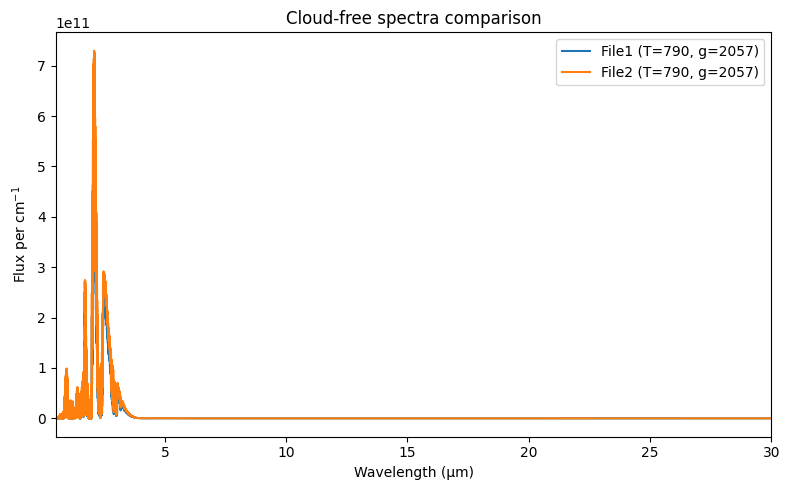

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(wl1, F1, lw=1.5, label=f"File1 (T={T1:.0f}, g={g1:.0f})")
plt.plot(wl2, F2, lw=1.5, label=f"File2 (T={T2:.0f}, g={g2:.0f})")
plt.xlim(0.5, 30)
plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux per cm$^{-1}$")
plt.title("Cloud-free spectra comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
##### CLOUD CONFIGURATION

cloudfile1 = r"C:\Users\Alex\Desktop\Picaso\NN_project\compare_cases\Pt790.3769135035916g2056.7149450539773.npy"
cloudfile2 = r"C:\Users\Alex\Desktop\Picaso\NN_project\compare_cases\At790.3769135035916g2056.7149450539773.npy"

cloud_dict = {'Fe': '1', 'KCl': '2', 'Mg2SiO4': '3', 'MgSiO3': '4', 'Na2S': '5'}

digit_to_species = {v: k for k, v in cloud_dict.items()}


def cloudy_name(path):
    base = os.path.basename(path)
    pat  = r"t(?P<T>[0-9.]+)g(?P<g>[0-9.]+)f(?P<fsed>[0-9.]+)k(?P<kzz>[\deE.+-]+)c(?P<codes>[0-9]+)\.npy$"
    m = re.search(pat, base)
    if m is None:
        raise ValueError(f"Could not parse: {base}")

    T    = float(m.group("T"))
    g = float(m.group("g"))          # cgs, dex
    fsed = float(m.group("fsed"))
    kzz  = m.group("kzz")                  # keep as string like "1e10"
    code_str = m.group("codes")
    clouds_used = [digit_to_species.get(d, f"code{d}") for d in code_str]

    return T, g, fsed, kzz, clouds_used

def cloudy_flux(file):
    cloudyFLUX = np.load(file, allow_pickle=True)
    # Creating wavenumber grid - HALF OF PETER SO FAR, CHANGE WHEN RUNNING 30 MICRON
    wnminc, wnmaxc  = 666.7, 20000.0
    wnc             = np.linspace(wnmaxc, wnminc, cloudyFLUX.size)
    # Convert to micron, should be 0.5 to 30 micron
    wlc             = 1e4 / wnc
    wlminc, wlmaxc  = np.min(wlc), np.max(wlc)
    # Convert FLUX to per micron
    cloudyFLM       = cloudyFLUX * (1e4 / wlc**2)
    # Sort
    idxc            = np.argsort(wlc)
    wlc_val         = wlc[idxc]
    flc_val         = cloudyFLM[idxc]
    flc_valog       = cloudyFLUX[idxc]
    return wlc_val, flc_valog

# Load files
wlc1, Fc1 = cloudy_flux(cloudfile1)
wlc2, Fc2 = cloudy_flux(cloudfile2)

clT1, cg1, fsed1, kzz1, clouds1 = cloudy_name(cloudfile1)
clT2, cg2, fsed2, kzz2, clouds2 = cloudy_name(cloudfile2)

In [ ]:
plt.figure(figsize=(8,5))
lab1 = f"T={clT1:.0f}, logg={cg1:.2f}, f{fsed1:g}, k{str(kzz1)}"
lab2 = f"T={clT2:.0f}, logg={cg2:.2f}, f{fsed2:g}, k{str(kzz2)}"

plt.plot(wlc1, Fc1, lw=1.4, label=lab1)
plt.plot(wlc2, Fc2, lw=1.4, label=lab2)

# Adjust x-limits to your coverage
plt.xlim(0.5, 30)   # safe, even if data stop at ~15 μm; the tail will be empty
plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux per cm$^{-1}$")
plt.title("Cloudy spectra (two cases)")
plt.legend()
plt.tight_layout()
plt.show()